In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import joblib

def prepare_ml_data():
    """
    Loads the cleaned dataset, applies LabelEncoder to categorical features,
    separates the target variable (price), and splits data into training and testing sets.
    """
    try:
        df = pd.read_csv("cleaned_cars_data.csv")
        encoders = {}
        categorical_cols = ["brand", "model", "fuel", "engine_type", "drivetrain", "transmission"]

        """ Iterates through categorical columns and encodes them into numeric values """
        for col in categorical_cols:
            try:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                encoders[col] = le
            except Exception as e:
                print("Encoding error: " + str(e))

        X = df.drop(columns=["price", "image_path"])
        y = df["price"]

        input_features = X.columns.tolist()
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        return X_train, X_test, y_train, y_test, input_features, encoders
    except Exception as e:
        print("Data prep error: " + str(e))
        return None, None, None, None, [], {}

try:
    """ Executes the data preparation pipeline """
    X_train, X_test, y_train, y_test, input_features, encoders = prepare_ml_data()
except Exception as e:
    print("Fatal prep error: " + str(e))

 METRICS 
MSE: 18158561789.942574
MAE: 91503.67768522425

 RULES 
|--- year <= 2018.50
|   |--- power_kw <= 135.50
|   |   |--- year <= 2015.50
|   |   |   |--- value: [209296.59]
|   |   |--- year >  2015.50
|   |   |   |--- value: [320554.92]
|   |--- power_kw >  135.50
|   |   |--- mileage_km <= 162594.00
|   |   |   |--- value: [493834.59]
|   |   |--- mileage_km >  162594.00
|   |   |   |--- value: [359793.52]
|--- year >  2018.50
|   |--- power_kw <= 141.00
|   |   |--- transmission <= 0.50
|   |   |   |--- value: [500274.22]
|   |   |--- transmission >  0.50
|   |   |   |--- value: [391601.37]
|   |--- power_kw >  141.00
|   |   |--- mileage_km <= 60115.50
|   |   |   |--- value: [1060428.57]
|   |   |--- mileage_km >  60115.50
|   |   |   |--- value: [660180.79]


 THRESHOLDS 
[ 2.01850e+03  1.35500e+02  2.01550e+03 -2.00000e+00 -2.00000e+00
  1.62594e+05 -2.00000e+00 -2.00000e+00  1.41000e+02  5.00000e-01
 -2.00000e+00 -2.00000e+00  6.01155e+04 -2.00000e+00 -2.00000e+00]


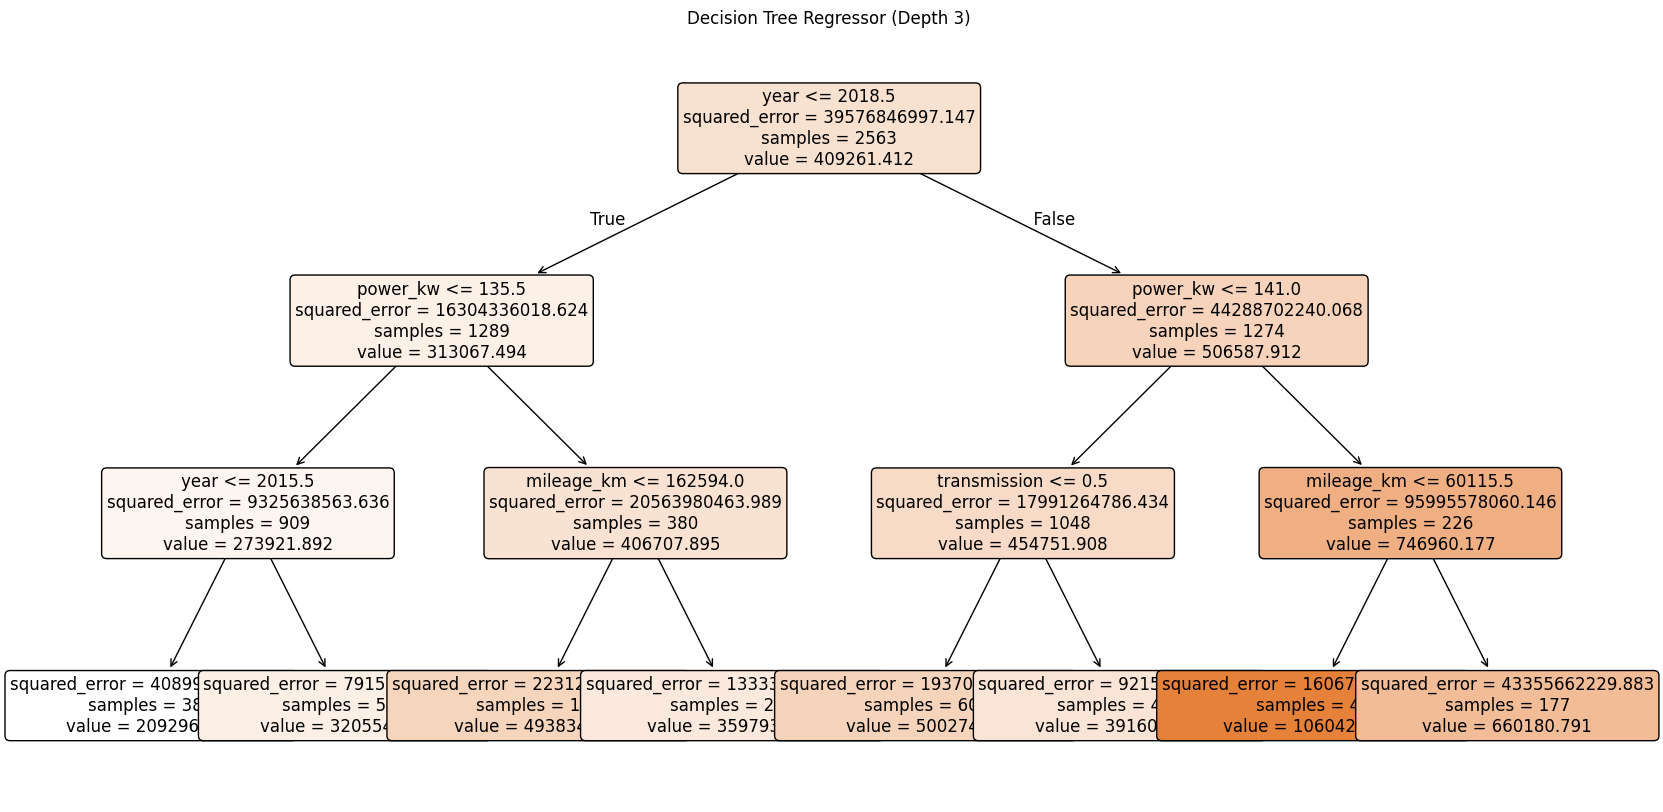

In [3]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

def run_decision_tree(X_train, X_test, y_train, y_test, input_features):
    """
    Trains a simple Decision Tree Regressor with a maximum depth of 3.
    Evaluates the model and visualizes the decision rules both as text and as a plot.
    """
    try:
        model = DecisionTreeRegressor(max_depth=3)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        mae = mean_absolute_error(y_test, preds)

        print(" METRICS ")
        print("MSE: " + str(mse))
        print("MAE: " + str(mae))

        print("\n RULES ")
        tree_rules = export_text(model, feature_names=input_features)
        print(tree_rules)

        print("\n THRESHOLDS ")
        print(model.tree_.threshold)

        try:
            """ Plots the graphical representation of the decision tree """
            plt.figure(figsize=(20, 10))
            plot_tree(model, feature_names=input_features, filled=True, rounded=True, fontsize=12)
            plt.title("Decision Tree Regressor (Depth 3)")
            plt.show()
        except Exception as e:
            print("Plotting error: " + str(e))

        return mse, mae
    except Exception as e:
        print("Decision tree error: " + str(e))
        return None, None

try:
    dt_mse, dt_mae = run_decision_tree(X_train, X_test, y_train, y_test, input_features)
except Exception as e:
    print("Fatal DT error: " + str(e))

RANDOM FOREST 
MSE: 6605686960.99844
MAE: 49214.633385335415

 FEATURE IMPORTANCES
brand: 0.03329710139567034
model: 0.05039363703213769
year: 0.3602409725189673
mileage_km: 0.13921552016573624
fuel: 0.02228275372265907
engine_type: 0.06923305978086713
power_kw: 0.2836815741204906
drivetrain: 0.01422963339738523
transmission: 0.02742574786608635

 VISUALIZING ONE TREE FROM FOREST ---


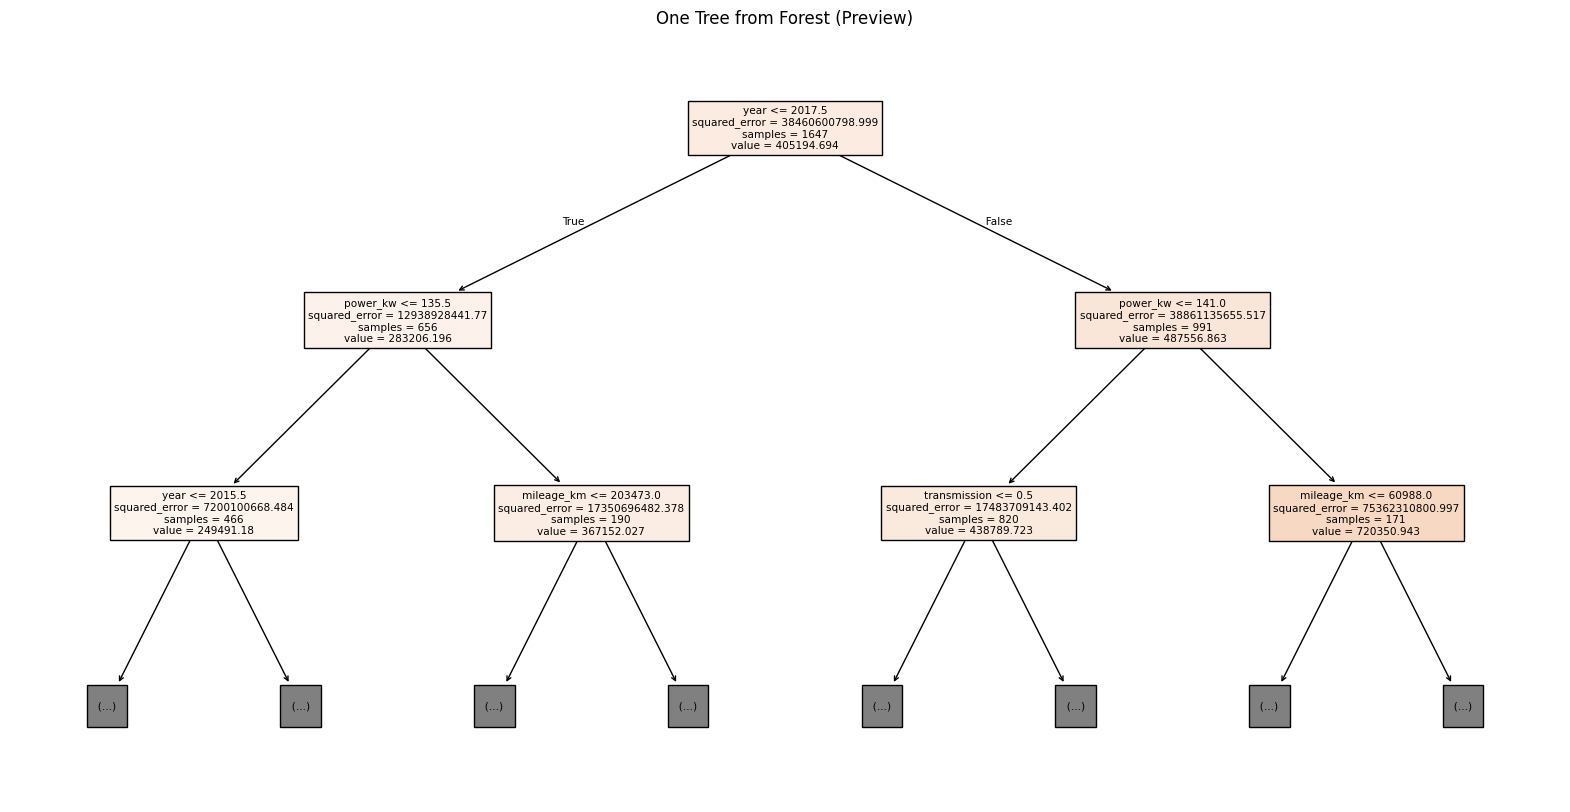

In [7]:
from sklearn.ensemble import RandomForestRegressor

def run_random_forest(X_train, X_test, y_train, y_test, input_features):
    """
    Trains a Random Forest Regressor with 50 estimators for higher accuracy.
    Evaluates the model, displays feature importances, and saves the final model to disk.
    """
    try:
        model = RandomForestRegressor(n_estimators=50, random_state=42)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)
        mse = mean_squared_error(y_test, preds)
        mae = mean_absolute_error(y_test, preds)

        print("RANDOM FOREST ")
        print("MSE: " + str(mse))
        print("MAE: " + str(mae))

        print("\n FEATURE IMPORTANCES")
        """ Displays the weight/importance of each feature in the final prediction """
        for feat, imp in zip(input_features, model.feature_importances_):
            print(feat + ": " + str(imp))

        print("\n VISUALIZING ONE TREE FROM FOREST ---")
        try:
            """ Visualizes just the very first tree from the entire random forest """
            tree_in_forest = model.estimators_[0]
            plt.figure(figsize=(20, 10))
            plot_tree(tree_in_forest, feature_names=input_features, filled=True, max_depth=2)
            plt.title("One Tree from Forest (Preview)")
            plt.show()
        except Exception as e:
            print("Forest plot error: " + str(e))

        """ Saves the trained Random Forest and LabelEncoders for the UI application """
        joblib.dump(model, "price_model.pkl")
        joblib.dump(encoders, "encoders.pkl")

        return mse, mae
    except Exception as e:
        print("Random forest error: " + str(e))
        return None, None

try:
    rf_mse, rf_mae = run_random_forest(X_train, X_test, y_train, y_test, input_features)
except Exception as e:
    print("Fatal RF error: " + str(e))

In [5]:
def show_comparison(dt_mse, dt_mae, rf_mse, rf_mae):
    """ Compares the accuracy of the Decision Tree and Random Forest side-by-side """
    try:
        data = {
            "Metric": ["MSE (Lower is better)", "MAE (Lower is better)"],
            "Decision Tree": [dt_mse, dt_mae],
            "Random Forest": [rf_mse, rf_mae]
        }
        comparison_df = pd.DataFrame(data)
        print("\n--- FINAL MODEL COMPARISON ---")
        display(comparison_df)
    except Exception as e:
        print("Comparison table error: " + str(e))

try:
    show_comparison(dt_mse, dt_mae, rf_mse, rf_mae)
except Exception as e:
    print("Fatal comparison error: " + str(e))


--- FINAL MODEL COMPARISON ---


,Metric,Decision Tree,Random Forest
0,MSE (Lower is better),1.815856e+10,6.605687e+09
1,MAE (Lower is better),9.150368e+04,4.921463e+04


In [8]:
from google.colab import drive
try:
    drive.mount('/content/drive')
    print("Google Drive successfully mounted.")
except Exception as e:
    print("Error mounting Google Drive: " + str(e))

Mounted at /content/drive
Google Drive successfully mounted.


In [9]:
import os
import shutil
import pandas as pd

def sort_images():
    """
    Reads the dataset and automatically sorts raw images from a single folder
    into subfolders based on the car brand. This is required for Keras dataset loading.
    """
    try:
        csv_path = "/content/drive/MyDrive/cleaned_cars_data.csv"
        df = pd.read_csv(csv_path)

        base_dir = "/content/drive/MyDrive/sorted_photos"
        source_dir = "/content/drive/MyDrive/cars_photos"

        try:
            os.makedirs(base_dir, exist_ok=True)
        except Exception as e:
            pass

        """ Iterates through every row to map the image path to its brand """
        for index, row in df.iterrows():
            try:
                brand = str(row["brand"])
                img_path = str(row["image_path"])

                img_name = os.path.basename(img_path)
                source = os.path.join(source_dir, img_name)

                target_dir = os.path.join(base_dir, brand)
                try:
                    os.makedirs(target_dir, exist_ok=True)
                except Exception as e:
                    pass

                target = os.path.join(target_dir, img_name)

                try:
                    if os.path.exists(source) and not os.path.exists(target):
                        shutil.copy(source, target)
                except Exception as e:
                    print("Error copying file " + img_name + ": " + str(e))
            except Exception as e:
                pass

        print("Sorting complete. Check /content/drive/MyDrive/sorted_photos")
    except Exception as e:
        print("Error reading csv for sorting: " + str(e))

try:
    sort_images()
except Exception as e:
    print("Fatal error in sorting: " + str(e))

Sorting complete. Check /content/drive/MyDrive/sorted_photos


In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
import json

def train_vision_improved():
    """
    Compiles and trains a Convolutional Neural Network (MobileNetV2) using transfer learning.
    Includes data augmentation, preprocessing, and fine-tuning for better brand recognition.
    """
    try:
        data_dir = "/content/drive/MyDrive/sorted_photos"

        train_ds = image_dataset_from_directory(
            data_dir, validation_split=0.2, subset="training", seed=42, image_size=(224, 224), batch_size=32
        )
        val_ds = image_dataset_from_directory(
            data_dir, validation_split=0.2, subset="validation", seed=42, image_size=(224, 224), batch_size=32
        )

        class_names = train_ds.class_names
        try:
            """ Saves the detected class names to a JSON file for the UI app to use later """
            with open("/content/drive/MyDrive/class_names.json", "w") as f:
                json.dump(class_names, f)
        except Exception as e:
            pass

        try:
            """ Applies MobileNetV2 specific pixel scaling (-1 to 1) """
            train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
            val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
        except Exception as e:
            pass

        """ Data augmentation layer to prevent overfitting and improve generalization """
        data_augmentation = Sequential([
            RandomFlip("horizontal"),
            RandomRotation(0.1),
            RandomZoom(0.1),
        ])

        base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
        base_model.trainable = True

        try:
            """ Freezes the first 100 layers of the pre-trained Google model """
            for layer in base_model.layers[:100]:
                layer.trainable = False
        except Exception as e:
            pass

        inputs = tf.keras.Input(shape=(224, 224, 3))

        try:
            x = data_augmentation(inputs)
            x = base_model(x, training=False)
            x = GlobalAveragePooling2D()(x)
            outputs = Dense(len(class_names), activation="softmax")(x)
        except Exception as e:
            pass

        model = Model(inputs, outputs)

        try:
            model.compile(
                optimizer=Adam(learning_rate=0.0001),
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"]
            )
        except Exception as e:
            pass

        model.fit(train_ds, validation_data=val_ds, epochs=10)

        try:
            model.save("/content/drive/MyDrive/brand_classifier.h5")
            print("Improved vision model saved to Drive.")
        except Exception as e:
            pass

    except Exception as e:
        print("Vision error: " + str(e))

try:
    train_vision_improved()
except Exception as e:
    pass

Found 3204 files belonging to 39 classes.
Using 2564 files for training.
Found 3204 files belonging to 39 classes.
Using 640 files for validation.
Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 275s 3s/step - accuracy: 0.4715 - loss: 2.0942 - val_accuracy: 0.5875 - val_loss: 1.8176
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 263s 3s/step - accuracy: 0.7492 - loss: 0.9819 - val_accuracy: 0.6547 - val_loss: 1.3604
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.8495 - loss: 0.5941 - val_accuracy: 0.6828 - val_loss: 1.2600
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.9060 - loss: 0.3845 - val_accuracy: 0.7172 - val_loss: 1.1131
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.9364 - loss: 0.2723 - val_accuracy: 0.7453 - val_loss: 1.0452
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.9575 - loss: 0.1910 - val_accuracy: 0.7547 - val_loss: 0.9432
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 261s 3s/step - accuracy: 0.9657 - loss: 0.1596 - val_

Improved vision model saved to Drive.


In [16]:
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

def evaluate_model():
    """
    Loads the trained Random Forest model and data from disk to perform a final
    evaluation. Calculates and prints standard error metrics.
    """
    try:
        df = pd.read_csv("cleaned_cars_data.csv")
        model = joblib.load("price_model.pkl")
        encoders = joblib.load("encoders.pkl")

        cat_cols = ["brand", "model", "fuel", "engine_type", "drivetrain", "transmission"]
        for c in cat_cols:
            try:
                df[c] = encoders[c].transform(df[c].astype(str))
            except Exception as e:
                pass

        """ Forces the exact column order required by the pre-trained model """
        expected_order = ['brand', 'model', 'year', 'mileage_km', 'fuel', 'engine_type', 'power_kw', 'drivetrain', 'transmission']

        try:
            X = df[expected_order]
        except Exception as e:
            pass

        y = df["price"]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        preds = model.predict(X_test)

        mae = mean_absolute_error(y_test, preds)
        mse = mean_squared_error(y_test, preds)

        try:
            rmse = np.sqrt(mse)
        except Exception as e:
            rmse = 0

        r2 = r2_score(y_test, preds)

        print("--- PRICE PREDICTION METRICS ---")
        print("Mean Absolute Error (CZK): " + str(round(mae, 2)))
        print("Mean Squared Error: " + str(round(mse, 2)))
        print("Root Mean Squared Error (CZK): " + str(round(rmse, 2)))
        print("Accuracy (R2 Score): " + str(round(r2, 4)))

    except Exception as e:
        print(str(e))

try:
    evaluate_model()
except Exception as e:
    print(str(e))

--- PRICE PREDICTION METRICS ---
Mean Absolute Error (CZK): 49214.63
Mean Squared Error: 6605686961.0
Root Mean Squared Error (CZK): 81275.38
Accuracy (R2 Score): 0.8561
